<a href="https://colab.research.google.com/github/amaimanwar8-arch/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/amaimanwar8-arch/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np, json
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print("Working dir:", os.getcwd())
print(df.shape[0], "pages loaded successfully.")

Working dir: /content/flyrank-ml-internship
30000 pages loaded successfully.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
scored = df[df["impressions_90d"] >= 100].copy()

tier_avg_ctr = scored.groupby("position_tier")["ctr"].transform("mean")
scored["ctr_gap"] = (tier_avg_ctr - scored["ctr"]).clip(lower=0)
scored["ctr_gap_norm"] = scored["ctr_gap"] / scored["ctr_gap"].max()
scored["aging_flag"] = (scored["freshness_tier"] == "91-180").astype(int)
scored["action_score"] = (0.65 * scored["ctr_gap_norm"]) + (0.35 * scored["aging_flag"])

# Expand into a small set of distinct reason codes / actions, not just one bucket
def assign_action(row):
    if row["ctr_gap_norm"] > 0.5 and row["aging_flag"] == 1:
        return "ctr_gap_and_aging_review", "rewrite_title_and_refresh"
    elif row["ctr_gap_norm"] > 0.5:
        return "ctr_gap_only", "rewrite_title_or_meta"
    elif row["aging_flag"] == 1:
        return "aging_only", "review_for_refresh"
    else:
        return "low_priority", "monitor"

scored[["reason_code", "action"]] = scored.apply(lambda r: pd.Series(assign_action(r)), axis=1)

queue = scored.sort_values("action_score", ascending=False)[
    ["content_id", "position_tier", "ctr", "ctr_gap", "freshness_tier",
     "action_score", "reason_code", "action"]
]

print("Action distribution:")
print(queue["action"].value_counts())
print("\nTop 5:")
queue.head()

Action distribution:
action
monitor                      10289
review_for_refresh            5924
rewrite_title_or_meta         3633
rewrite_title_and_refresh     2160
Name: count, dtype: int64

Top 5:


,content_id,position_tier,ctr,ctr_gap,freshness_tier,action_score,reason_code,action
21358,content_5352bbcea612,page_1,0.0,0.35476,91-180,1.0,ctr_gap_and_aging_review,rewrite_title_and_refresh
9646,content_384b06d9d970,page_1,0.0,0.35476,91-180,1.0,ctr_gap_and_aging_review,rewrite_title_and_refresh
22374,content_761694ab97b4,page_1,0.0,0.35476,91-180,1.0,ctr_gap_and_aging_review,rewrite_title_and_refresh
4156,content_6ff59596237d,page_1,0.0,0.35476,91-180,1.0,ctr_gap_and_aging_review,rewrite_title_and_refresh
24472,content_8db4c9e4360b,page_1,0.0,0.35476,91-180,1.0,ctr_gap_and_aging_review,rewrite_title_and_refresh


In [3]:
print("""
Ranked actions + reason codes:

rewrite_title_and_refresh (n=2,160) | reason: ctr_gap_and_aging_review
  Pages with both a large CTR gap vs. their own position tier AND sitting in the 91-180
  day aging zone (Week-4's confirmed peak-decline window). Highest priority - two
  independent signals agree.

rewrite_title_or_meta (n=3,633) | reason: ctr_gap_only
  Strong CTR gap, but not in the aging zone. Likely a metadata/snippet problem rather
  than staleness - the fix is narrower (title/meta), not a full content refresh.

review_for_refresh (n=5,924) | reason: aging_only
  In the confirmed 91-180 aging zone, but CTR is not notably below its tier average.
  Content may just need a light freshness pass, not a rewrite.

monitor (n=10,289) | reason: low_priority
  Neither signal is triggered strongly. No action needed now - just keep tracking.

This maps my baseline's two validated signals (CTR gap: CONFIRMED, aging: MIXED but real
in the 91-180 zone) into four distinct actions instead of one flat "review" bucket, so a
content team can prioritize by which specific problem a page actually has.
""")


Ranked actions + reason codes:

rewrite_title_and_refresh (n=2,160) | reason: ctr_gap_and_aging_review
  Pages with both a large CTR gap vs. their own position tier AND sitting in the 91-180
  day aging zone (Week-4's confirmed peak-decline window). Highest priority - two
  independent signals agree.

rewrite_title_or_meta (n=3,633) | reason: ctr_gap_only
  Strong CTR gap, but not in the aging zone. Likely a metadata/snippet problem rather
  than staleness - the fix is narrower (title/meta), not a full content refresh.

review_for_refresh (n=5,924) | reason: aging_only
  In the confirmed 91-180 aging zone, but CTR is not notably below its tier average.
  Content may just need a light freshness pass, not a rewrite.

monitor (n=10,289) | reason: low_priority
  Neither signal is triggered strongly. No action needed now - just keep tracking.

This maps my baseline's two validated signals (CTR gap: CONFIRMED, aging: MIXED but real
in the 91-180 zone) into four distinct actions instead of o

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [4]:
print("""
Intended use: this playbook is decision-SUPPORT for a content reviewer with limited
capacity - it ranks candidates for a human to look at first, using signals validated in
Week 4 (ML-07) and re-confirmed in Week 6 (ML-09). It is not an autonomous action system.

Why the baseline, not the model: Week 5/6's honest client-grouped validation showed my
random forest LOST to this same baseline rule (Precision@50: 0.760 model vs. 0.840
baseline) on genuinely unseen clients. Shipping the model here would mean shipping a
worse-performing system than the simple rule, just because it "feels" more advanced -
exactly the trap the lane guide warns against ("does not reward complexity alone").

Limits: this queue is built entirely on the small 30,000-row anonymized starter dataset,
not the full ~79M-row warehouse - it has not been re-validated at that scale. The aging
signal (91-180 days) is MIXED, not fully confirmed, and rests on small tail-bucket samples
(Week 4's 31-90/181+ tiers had n=174-175). This playbook says nothing about WHY a page is
underperforming (title quality, search intent mismatch, competitor movement) - only THAT
it's a candidate worth a human look.
""")


Intended use: this playbook is decision-SUPPORT for a content reviewer with limited
capacity - it ranks candidates for a human to look at first, using signals validated in
Week 4 (ML-07) and re-confirmed in Week 6 (ML-09). It is not an autonomous action system.

Why the baseline, not the model: Week 5/6's honest client-grouped validation showed my
random forest LOST to this same baseline rule (Precision@50: 0.760 model vs. 0.840
baseline) on genuinely unseen clients. Shipping the model here would mean shipping a
worse-performing system than the simple rule, just because it "feels" more advanced -
exactly the trap the lane guide warns against ("does not reward complexity alone").

Limits: this queue is built entirely on the small 30,000-row anonymized starter dataset,
not the full ~79M-row warehouse - it has not been re-validated at that scale. The aging
signal (91-180 days) is MIXED, not fully confirmed, and rests on small tail-bucket samples
(Week 4's 31-90/181+ tiers had n=174-175).

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [5]:
print("""
Human review checklist - before acting on ANY row in this queue, a reviewer should check:

1. Does the page's real intent match a "content problem" story? A branded/navigational
   page can have a low CTR for reasons that have nothing to do with content quality (users
   already know what they want and don't need to read a snippet).
2. Is this page recently affected by a SERP feature change (featured snippet, AI overview)
   rather than an actual content or freshness issue? This data cannot distinguish that.
3. Is the page part of a consolidation pattern - did a sibling page on the same site
   absorb this page's traffic? Check related content before assuming decline.
4. Does the reviewer have capacity? The queue is 22,006 rows; realistically only a
   handful can be reviewed at once. Use the score ranking, not the whole file.

The no-go list - things this playbook must NEVER be used for:
- Automatically editing, rewriting, or publishing content without human review.
- Claiming a page WILL recover if refreshed - this data cannot prove causation, only rank
  candidates for review (per the lane guide's own rule).
- Treating "monitor" pages as confirmed safe - it means no strong signal was found, not
  that the page has zero problems.
- Sharing this queue outside the organization with content_id values intact if there's
  any risk they could be mapped back to real URLs - they're pseudonymized here but the
  discipline should hold regardless.
""")


Human review checklist - before acting on ANY row in this queue, a reviewer should check:

1. Does the page's real intent match a "content problem" story? A branded/navigational
   page can have a low CTR for reasons that have nothing to do with content quality (users
   already know what they want and don't need to read a snippet).
2. Is this page recently affected by a SERP feature change (featured snippet, AI overview)
   rather than an actual content or freshness issue? This data cannot distinguish that.
3. Is the page part of a consolidation pattern - did a sibling page on the same site
   absorb this page's traffic? Check related content before assuming decline.
4. Does the reviewer have capacity? The queue is 22,006 rows; realistically only a
   handful can be reviewed at once. Use the score ranking, not the whole file.

The no-go list - things this playbook must NEVER be used for:
- Automatically editing, rewriting, or publishing content without human review.
- Claiming a page

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [6]:
print("""
Monitoring / retrain triggers - signs this playbook has gone stale:

1. Signal drift: if a future signal audit shows CTR-by-position-tier is no longer cleanly
   monotonic (Week 4's CONFIRMED result), the core assumption behind 65% of the score has
   broken and the rule needs rebuilding, not just reweighting.
2. Action distribution shift: if re-running this notebook on fresh data produces a wildly
   different split across the four action buckets (e.g. "monitor" drops from ~47% to
   under 10%), that's worth investigating before trusting the new queue blindly.
3. Reviewer feedback loop: if reviewers consistently mark high-score pages as "wrong call"
   (the no-go-list style disagreement), that's a signal the rule's weights (65/35) need
   re-tuning against real outcomes, not just re-running as-is.
4. Time-based refresh: given this uses a 30,000-row anonymized STARTER slice, not the full
   warehouse, any production use would need to re-derive the CTR-by-tier and aging-zone
   numbers on current warehouse data before trusting them again - these are not permanent
   constants.
""")


Monitoring / retrain triggers - signs this playbook has gone stale:

1. Signal drift: if a future signal audit shows CTR-by-position-tier is no longer cleanly
   monotonic (Week 4's CONFIRMED result), the core assumption behind 65% of the score has
   broken and the rule needs rebuilding, not just reweighting.
2. Action distribution shift: if re-running this notebook on fresh data produces a wildly
   different split across the four action buckets (e.g. "monitor" drops from ~47% to
   under 10%), that's worth investigating before trusting the new queue blindly.
3. Reviewer feedback loop: if reviewers consistently mark high-score pages as "wrong call"
   (the no-go-list style disagreement), that's a signal the rule's weights (65/35) need
   re-tuning against real outcomes, not just re-running as-is.
4. Time-based refresh: given this uses a 30,000-row anonymized STARTER slice, not the full
   warehouse, any production use would need to re-derive the CTR-by-tier and aging-zone
   numbers

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 22,006 rows to work/outputs/action_playbook_queue.csv
Wrote work/outputs/playbook_metrics.json


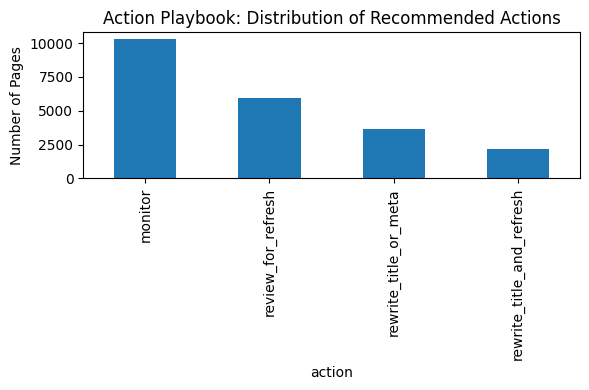

Saved work/figures/action_distribution.png


In [7]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# The ranked queue (regenerated each run, not committed to git - per the leak-guard)
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(queue):,} rows to work/outputs/action_playbook_queue.csv")

# Committed metrics JSON - the "receipts" the paper's numbers trace back to
metrics = {
    "signal_1_ctr_by_tier_verdict": "CONFIRMED",
    "signal_2_aging_by_tier_verdict": "MIXED",
    "baseline_precision_at_20_grouped": 0.850,
    "baseline_precision_at_50_grouped": 0.840,
    "model_precision_at_20_grouped": 0.650,
    "model_precision_at_50_grouped": 0.760,
    "action_distribution": queue["action"].value_counts().to_dict(),
    "total_ranked_rows": int(len(queue)),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/playbook_metrics.json")

# A figure worth reusing in the paper: action distribution bar chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
queue["action"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Action Playbook: Distribution of Recommended Actions")
ax.set_ylabel("Number of Pages")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()
print("Saved work/figures/action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.